In [4]:
#Quantum Optimization
from qiskit_algorithms import QAOA
from qiskit_algorithms.optimizers import COBYLA
from qiskit.primitives import StatevectorSampler
from qiskit_optimization.applications import Maxcut
from qiskit_optimization.translators import to_ising
import networkx as nx
graph = nx.Graph()
graph.add_edges_from([
(0,1),
(1,2),
(2,3),
(3,0)
])
maxcut = Maxcut(graph)
qp = maxcut.to_quadratic_program()
operator, offset = to_ising(qp)
optimizer = COBYLA(maxiter=100)
sampler = StatevectorSampler()
qaoa = QAOA(
    sampler=sampler,
    optimizer=optimizer,
    reps=2
)
result = qaoa.compute_minimum_eigenvalue(operator)
print(result)
print("Optimal bitstring :", result.best_measurement["bitstring"])
print("Probability       :", result.best_measurement["probability"])
print("Optimal value     :", result.optimal_value)
print("Eigenvalue        :", result.eigenvalue)
print("Cost evaluations  :", result.cost_function_evals)

/opt/anaconda3/lib/python3.13/site-packages/scipy/sparse/linalg/_dsolve/linsolve.py:606: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
/opt/anaconda3/lib/python3.13/site-packages/scipy/sparse/linalg/_matfuncs.py:707: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  return spsolve(Q, P)
/opt/anaconda3/lib/python3.13/site-packages/scipy/sparse/_index.py:168: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])


{   'aux_operators_evaluated': None,
    'best_measurement': {   'bitstring': '0101',
                            'probability': 0.2783203125,
                            'state': 5,
                            'value': np.complex128(-2+0j)},
    'cost_function_evals': np.int64(39),
    'eigenstate': {   '0000': 0.013671875,
                      '0001': 0.0234375,
                      '0010': 0.0283203125,
                      '0011': 0.056640625,
                      '0100': 0.03125,
                      '0101': 0.259765625,
                      '0110': 0.06640625,
                      '0111': 0.021484375,
                      '1000': 0.03125,
                      '1001': 0.0615234375,
                      '1010': 0.2421875,
                      '1011': 0.0302734375,
                      '1100': 0.0693359375,
                      '1101': 0.025390625,
                      '1110': 0.0302734375,
                      '1111': 0.0087890625},
    'eigenvalue': np.float64(-1.03

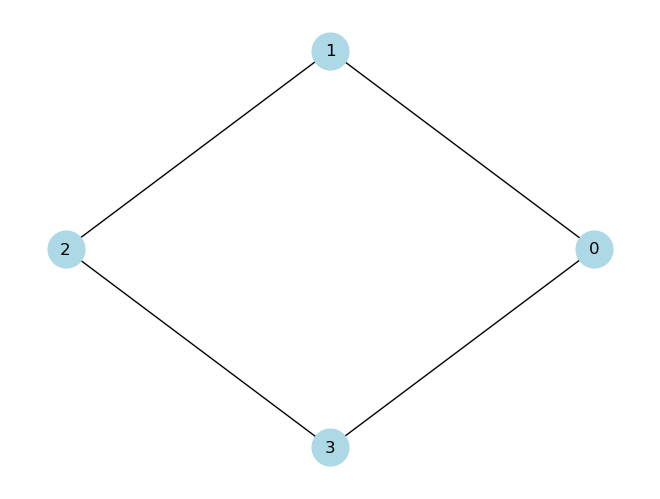

In [5]:
import matplotlib.pyplot as plt

pos = nx.circular_layout(graph)
nx.draw(
    graph,
    pos,
    with_labels=True,
    node_color="lightblue",
    node_size=700
)

plt.show()

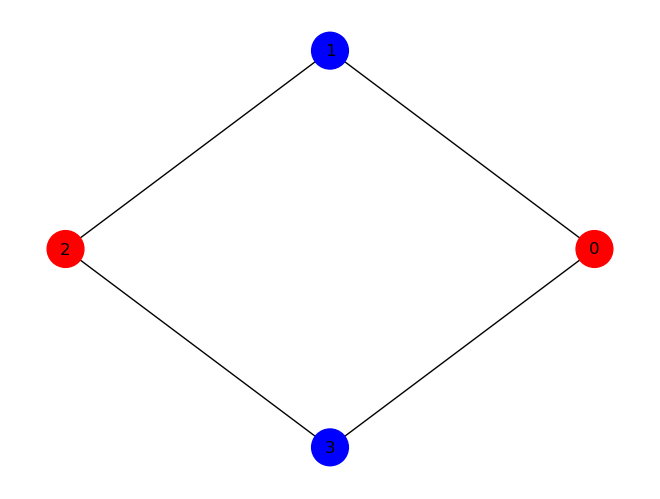

In [6]:
bitstring = result.best_measurement["bitstring"]

colors = ["red" if bit == "0" else "blue" for bit in bitstring]

pos = nx.circular_layout(graph)

nx.draw(
    graph,
    pos,
    with_labels=True,
    node_color=colors,
    node_size=700
)

plt.show()